# Claim-Occurrence Model Validation

This notebook reviews the first insurance classification model.

The model predicts whether a policy had at least one reported claim.

The notebook examines:

- training, validation, and test samples;
- the no-claim baseline;
- logistic-regression performance;
- threshold selection;
- class imbalance;
- confusion-matrix results;
- probability ranking;
- logistic-regression coefficients.

In [12]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "modeling"
    / "claim_occurrence"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "modeling"
    / "claim_occurrence"
)

METRICS_PATH = (
    REPORT_DIR
    / "claim_occurrence_metrics.csv"
)

SPLIT_PATH = (
    REPORT_DIR
    / "split_summary.csv"
)

COEFFICIENT_PATH = (
    REPORT_DIR
    / "logistic_coefficients.csv"
)

THRESHOLD_PATH = (
    REPORT_DIR
    / "test_threshold_comparison.csv"
)

PREDICTION_SAMPLE_PATH = (
    REPORT_DIR
    / "prediction_sample.csv"
)

print(f"Metrics exist: {METRICS_PATH.exists()}")
print(f"Split summary exists: {SPLIT_PATH.exists()}")
print(f"Coefficients exist: {COEFFICIENT_PATH.exists()}")

Metrics exist: True
Split summary exists: True
Coefficients exist: True


In [13]:
metrics = pd.read_csv(METRICS_PATH)
split_summary = pd.read_csv(SPLIT_PATH)
coefficients = pd.read_csv(COEFFICIENT_PATH)
thresholds = pd.read_csv(THRESHOLD_PATH)
prediction_sample = pd.read_csv(
    PREDICTION_SAMPLE_PATH
)

print("Data splits:")
display(split_summary)

print("Model metrics:")
display(metrics)

Data splits:


,Sample,Rows,Claims,NoClaims,ClaimRate
0,Training,406807,20436,386371,0.050235
1,Validation,135603,6812,128791,0.050235
2,Test,135603,6812,128791,0.050235


Model metrics:


,Model,Threshold,Accuracy,Precision,Recall,Specificity,NegativePredictiveValue,F1Score,F2Score,ROCAUC,PRAUC,BrierScore,TrueNegatives,FalsePositives,FalseNegatives,TruePositives,PredictedPositiveRate
0,No-claim baseline,0.500000,0.949765,0.000000,0.000000,1.000000,0.949765,0.000000,0.000000,0.500000,0.050235,0.047711,128791,0,6812,0,0.000000
1,Logistic regression — threshold 0.50,0.500000,0.949772,0.600000,0.000440,0.999984,0.949785,0.000880,0.000550,0.640154,0.091308,0.047011,128789,2,6809,3,0.000037
2,Logistic regression — selected threshold,0.050975,0.573254,0.071419,0.624486,0.570545,0.966359,0.128179,0.245012,0.640154,0.091308,0.047011,73481,55310,2558,4254,0.439253


In [14]:
metric_columns = [
    "Model",
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1Score",
    "F2Score",
    "ROCAUC",
    "PRAUC",
    "BrierScore",
    "PredictedPositiveRate",
]

display(
    metrics[
        metric_columns
    ]
)

,Model,Threshold,Accuracy,Precision,Recall,Specificity,F1Score,F2Score,ROCAUC,PRAUC,BrierScore,PredictedPositiveRate
0,No-claim baseline,0.500000,0.949765,0.000000,0.000000,1.000000,0.000000,0.000000,0.500000,0.050235,0.047711,0.000000
1,Logistic regression — threshold 0.50,0.500000,0.949772,0.600000,0.000440,0.999984,0.000880,0.000550,0.640154,0.091308,0.047011,0.000037
2,Logistic regression — selected threshold,0.050975,0.573254,0.071419,0.624486,0.570545,0.128179,0.245012,0.640154,0.091308,0.047011,0.439253


In [15]:
confusion_columns = [
    "Model",
    "TrueNegatives",
    "FalsePositives",
    "FalseNegatives",
    "TruePositives",
]

display(
    metrics[
        confusion_columns
    ]
)

,Model,TrueNegatives,FalsePositives,FalseNegatives,TruePositives
0,No-claim baseline,128791,0,6812,0
1,Logistic regression — threshold 0.50,128789,2,6809,3
2,Logistic regression — selected threshold,73481,55310,2558,4254


In [16]:
selected_model = metrics.loc[
    metrics["Model"].str.contains(
        "selected threshold",
        case=False,
    )
].iloc[0]

print(
    "Selected threshold:",
    f"{selected_model['Threshold']:.6f}",
)

print(
    "Precision:",
    f"{selected_model['Precision']:.2%}",
)

print(
    "Recall:",
    f"{selected_model['Recall']:.2%}",
)

print(
    "Predicted positive rate:",
    f"{selected_model['PredictedPositiveRate']:.2%}",
)

Selected threshold: 0.050975
Precision: 7.14%
Recall: 62.45%
Predicted positive rate: 43.93%


### Threshold Interpretation

The validation-selected probability threshold was approximately 0.051.

At this threshold, the model classified 43.93% of test policies as
positive and identified 62.45% of the policies that actually had a
claim.

Precision was 7.14%, compared with an overall test claim rate of
approximately 5.02%. Therefore, policies selected by the model were
about 1.42 times more likely to have a claim than a randomly selected
policy.

The threshold prioritizes recall through the F2-score. This improves
claim identification but produces a large number of false positives and
a substantial review workload.

The threshold should therefore be interpreted as a screening threshold,
not as a basis for automatically making insurance decisions.

In [17]:
threshold_view = thresholds.loc[
    thresholds["Threshold"].between(
        0.01,
        0.20,
    )
].copy()

display(
    threshold_view.sort_values(
        "Threshold"
    )
)

,Threshold,Precision,Recall,F1Score,F2Score,PredictedPositiveRate
0,0.010000,0.050597,0.998092,0.096312,0.210335,0.990944
1,0.015000,0.051355,0.989577,0.097643,0.212635,0.967995
2,0.020000,0.053115,0.974604,0.100740,0.218044,0.921750
3,0.025000,0.055081,0.945537,0.104098,0.223359,0.862348
4,0.030000,0.057264,0.904874,0.107712,0.228484,0.793795
5,0.035000,0.060068,0.859366,0.112286,0.234714,0.718694
6,0.040000,0.063312,0.802408,0.117363,0.240617,0.636675
7,0.045000,0.066800,0.729742,0.122396,0.244482,0.548778
8,0.050000,0.070475,0.640194,0.126973,0.244648,0.456332
9,0.050975,0.071419,0.624486,0.128179,0.245012,0.439253


In [18]:
positive_coefficients = (
    coefficients.loc[
        coefficients["Coefficient"] > 0
    ]
    .sort_values(
        "Coefficient",
        ascending=False,
    )
    .head(15)
)

negative_coefficients = (
    coefficients.loc[
        coefficients["Coefficient"] < 0
    ]
    .sort_values(
        "Coefficient",
        ascending=True,
    )
    .head(15)
)

print("Strongest positive coefficients:")
display(
    positive_coefficients[
        [
            "Feature",
            "Coefficient",
            "OddsRatio",
        ]
    ]
)

print("Strongest negative coefficients:")
display(
    negative_coefficients[
        [
            "Feature",
            "Coefficient",
            "OddsRatio",
        ]
    ]
)

Strongest positive coefficients:


,Feature,Coefficient,OddsRatio
0,numeric__LogExposure,0.438040,1.549668
2,numeric__BonusMalus,0.319329,1.376204
3,categorical__Region_R74,0.273930,1.315123
4,categorical__Region_R53,0.264642,1.302965
7,categorical__Region_R24,0.198661,1.219769
8,categorical__Region_R82,0.186579,1.205120
10,categorical__Region_R21,0.159501,1.172926
11,categorical__Region_R22,0.158395,1.171629
12,numeric__DrivAge,0.141793,1.152338
14,categorical__Region_R25,0.137242,1.147105


Strongest negative coefficients:


,Feature,Coefficient,OddsRatio
1,categorical__Region_R23,-0.331851,0.717594
5,categorical__Region_R83,-0.253302,0.776233
6,numeric__VehAge,-0.214509,0.806938
9,categorical__Region_R73,-0.172765,0.841335
13,categorical__Region_R91,-0.137315,0.871695
16,categorical__Region_R72,-0.107992,0.897635
17,categorical__Region_R43,-0.104165,0.901077
18,categorical__Region_R31,-0.087155,0.916535
24,categorical__Region_R41,-0.063015,0.938929
26,categorical__VehBrand_B6,-0.058046,0.943607


ROC curve:


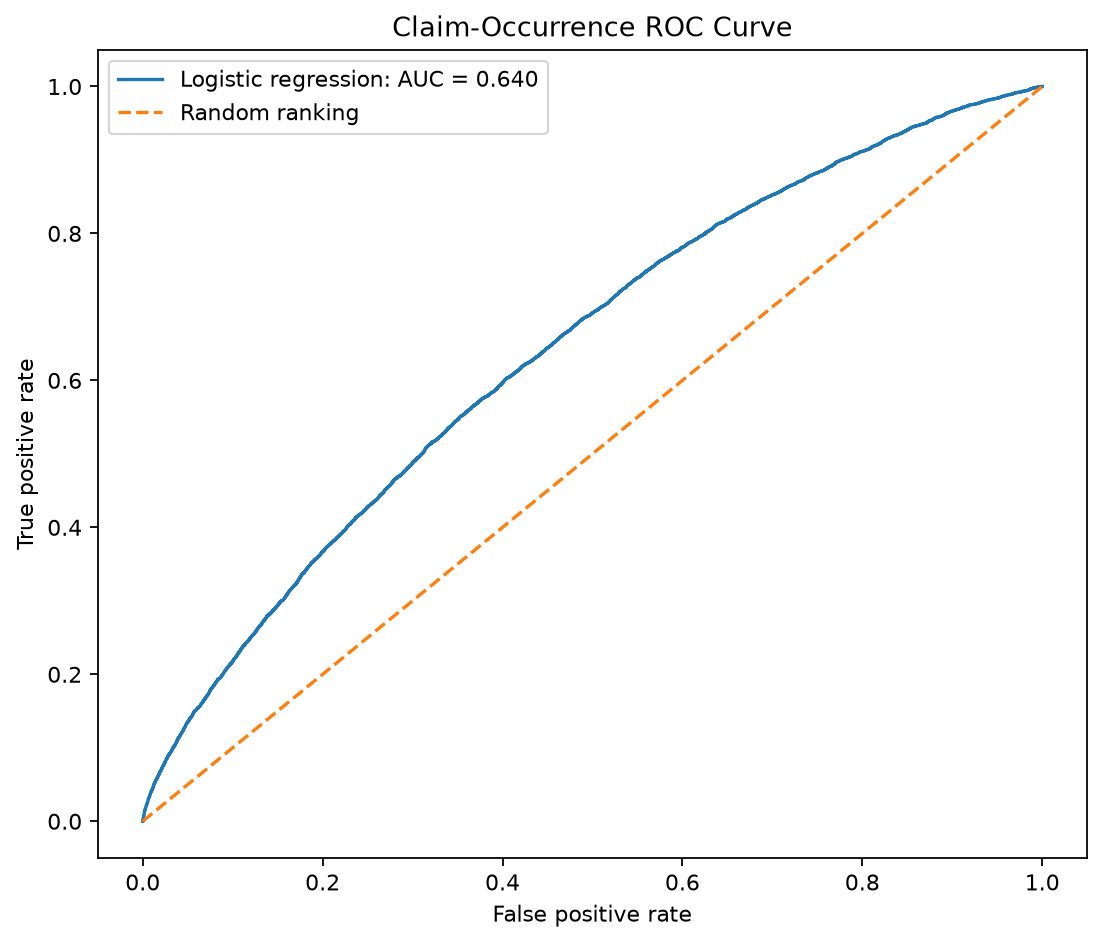

Precision-recall curve:


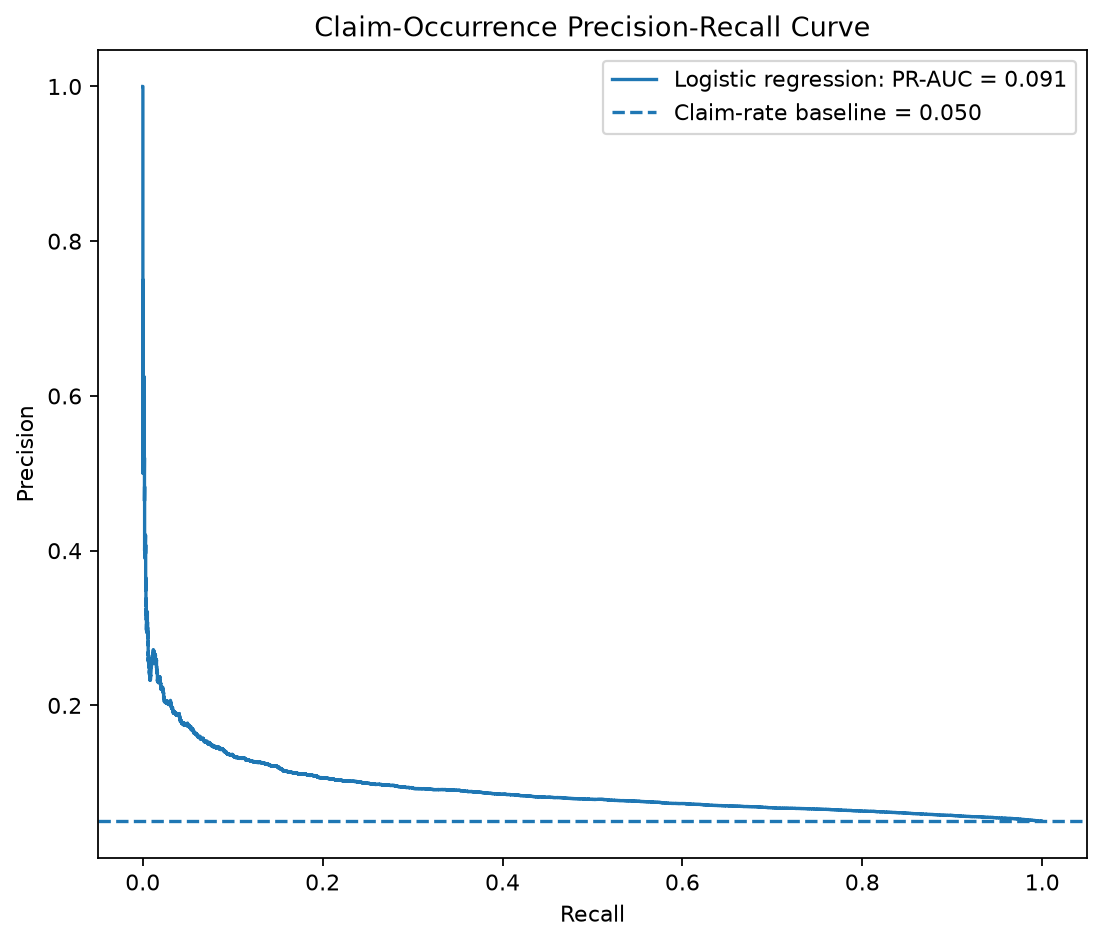

In [19]:
print("ROC curve:")
display(
    Image(
        filename=str(
            FIGURES_DIR
            / "claim_occurrence_roc_curve.png"
        )
    )
)

print("Precision-recall curve:")
display(
    Image(
        filename=str(
            FIGURES_DIR
            / "claim_occurrence_precision_recall_curve.png"
        )
    )
)

Confusion matrix:


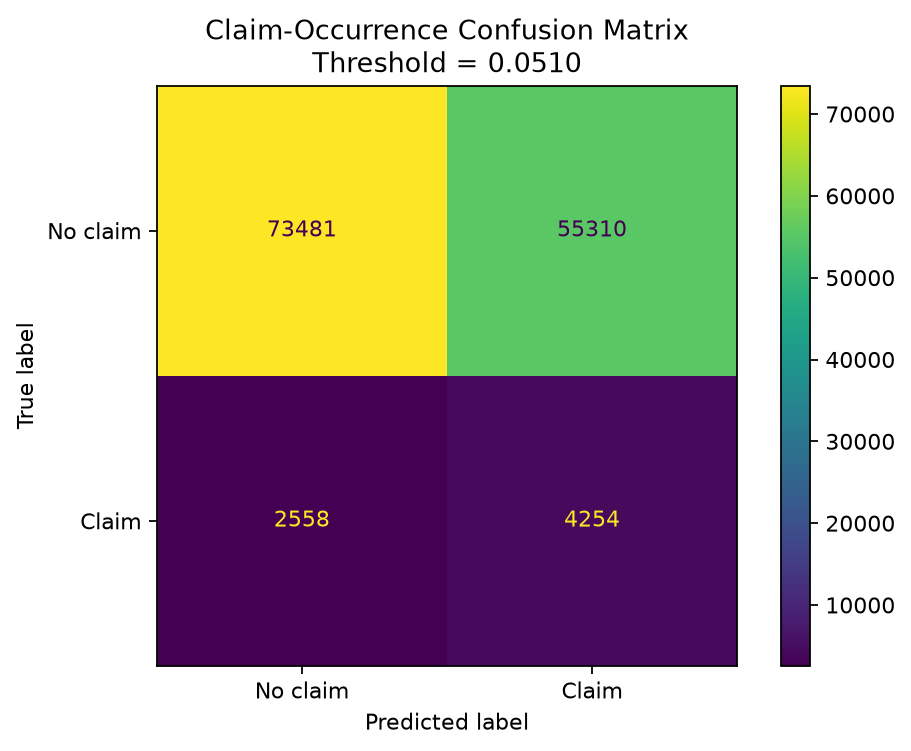

Calibration curve:


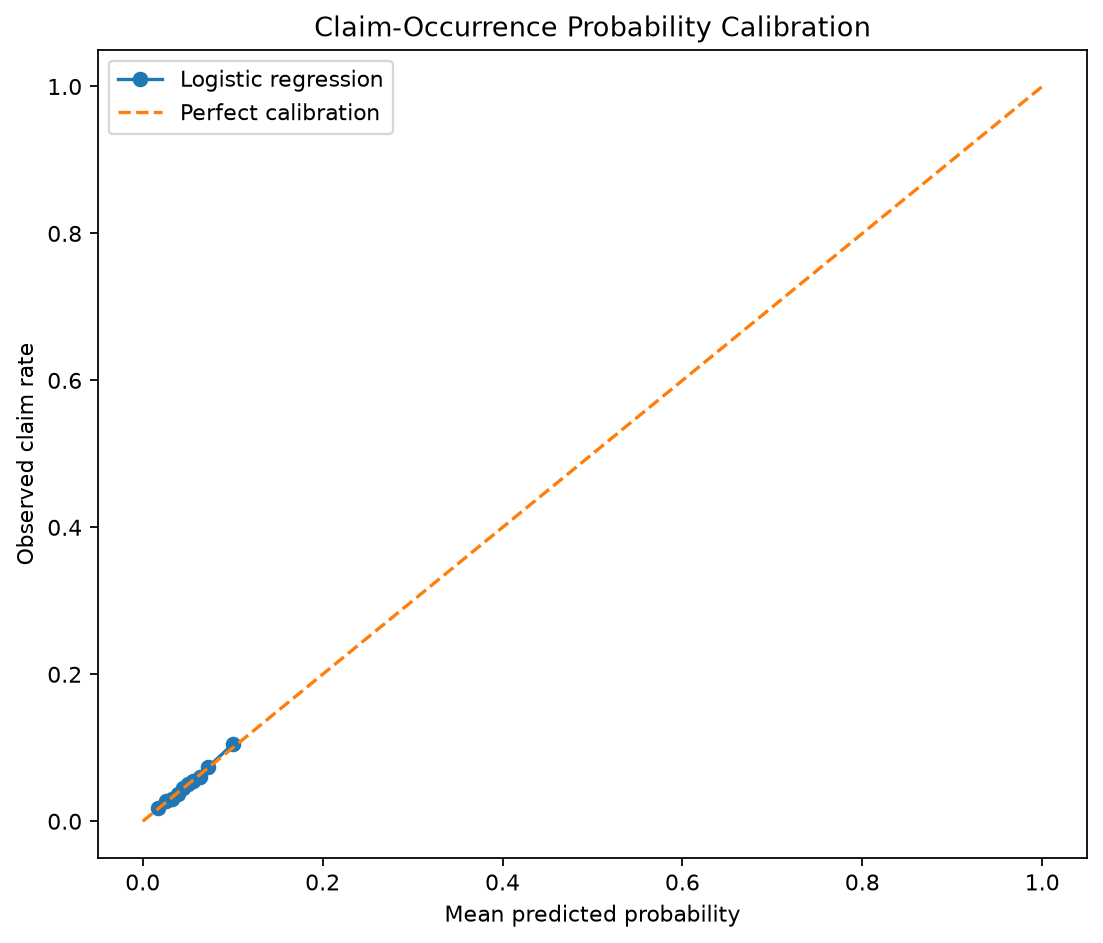

In [20]:
print("Confusion matrix:")
display(
    Image(
        filename=str(
            FIGURES_DIR
            / "claim_occurrence_confusion_matrix.png"
        )
    )
)

print("Calibration curve:")
display(
    Image(
        filename=str(
            FIGURES_DIR
            / "claim_occurrence_calibration.png"
        )
    )
)

In [21]:
display(
    prediction_sample.head(20)
)

,IDpol,Exposure,HasClaim,PredictedClaimProbability,PredictedClaimDefaultThreshold,PredictedClaimSelectedThreshold
0,4131011,0.750000,0,0.176662,0,1
1,2217797,0.080000,0,0.175350,0,1
2,6111532,0.540000,0,0.175054,0,1
3,2184304,0.840000,1,0.171784,0,1
4,1118498,0.730000,1,0.163011,0,1
5,4017318,0.700000,0,0.153450,0,1
6,4034672,0.580000,0,0.152627,0,1
7,176602,0.440000,0,0.141494,0,1
8,6095587,0.380000,0,0.140041,0,1
9,6096332,0.380000,0,0.137669,0,1


In [22]:
validation_checks = pd.DataFrame(
    {
        "Validation": [
            "Three evaluation rows exist",
            "Selected threshold is between zero and one",
            "ROC-AUC is at least 0.50",
            "PR-AUC exceeds zero",
            "Test sample contains predictions",
            "Coefficient table is non-empty",
        ],
        "Passed": [
            len(metrics) == 3,
            selected_model["Threshold"] > 0
            and selected_model["Threshold"] < 1,
            selected_model["ROCAUC"] >= 0.50,
            selected_model["PRAUC"] > 0,
            len(prediction_sample) > 0,
            len(coefficients) > 0,
        ],
    }
)

display(validation_checks)

,Validation,Passed
0,Three evaluation rows exist,True
1,Selected threshold is between zero and one,True
2,ROC-AUC is at least 0.50,True
3,PR-AUC exceeds zero,True
4,Test sample contains predictions,True
5,Coefficient table is non-empty,True
